In [2]:
import pandas as pd

In [6]:
# Step 1: test load small chunk
df_demo = pd.read_csv("df_final_demo.txt")

# Step 2: load only part of big file
df_web_1 = pd.read_csv("df_final_web_data_pt_1.txt", nrows=1000)

In [7]:
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [8]:
# basic structure
df_demo.shape

(70609, 9)

In [9]:
# column types + missing values
df_demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


In [10]:
# quick stats
df_demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.060900e+04,70595.000000,70595.000000,70594.000000,70595.000000,7.059500e+04,70595.000000,70595.000000
mean,5.004992e+06,12.052950,150.659367,46.442240,2.255528,1.474452e+05,3.382478,5.566740
std,2.877278e+06,6.871819,82.089854,15.591273,0.534997,3.015087e+05,2.236580,2.353286
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519329e+06,6.000000,82.000000,32.500000,2.000000,3.734683e+04,1.000000,4.000000
50%,5.016978e+06,11.000000,136.000000,47.000000,2.000000,6.333290e+04,3.000000,5.000000
75%,7.483085e+06,16.000000,192.000000,59.000000,2.000000,1.375449e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [11]:
# gender distribution
df_demo["gendr"].value_counts()

gendr
U    24122
M    23724
F    22746
X        3
Name: count, dtype: int64

In [12]:
# age overview
df_demo["clnt_age"].describe()

count    70594.000000
mean        46.442240
std         15.591273
min         13.500000
25%         32.500000
50%         47.000000
75%         59.000000
max         96.000000
Name: clnt_age, dtype: float64

In [14]:
df_exp = pd.read_csv("df_final_experiment_clients.txt")

In [15]:
df_exp.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [17]:
df_exp["Variation"].value_counts()

Variation
Test       26968
Control    23532
Name: count, dtype: int64

In [18]:
# missing values overview
df_demo.isna().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [19]:
# Check rows with any missing values
df_demo[df_demo.isna().any(axis=1)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# remove rows with missing values
df_demo_clean = df_demo.dropna()

In [21]:
df_demo_clean.shape

(70594, 9)

In [22]:
df_demo_clean["gendr"].value_counts()

gendr
U    24122
M    23724
F    22745
X        3
Name: count, dtype: int64

In [23]:
df_demo_clean["gendr"].value_counts(normalize=True)

gendr
U    0.341700
M    0.336063
F    0.322195
X    0.000042
Name: proportion, dtype: float64

### Gender distribution

- The dataset contains three main categories: M, F, and U (unknown).
- A significant portion (~34%) of users have unspecified gender ("U").
- Removing this group would lead to substantial data loss, so it is kept as a separate category for analysis.

In [24]:
df_demo_clean[["clnt_tenure_yr", "clnt_tenure_mnth"]].describe()

,clnt_tenure_yr,clnt_tenure_mnth
count,70594.000000,70594.000000
mean,12.053007,150.659999
std,6.871850,82.090264
min,2.000000,33.000000
25%,6.000000,82.000000
50%,11.000000,136.000000
75%,16.000000,192.000000
max,62.000000,749.000000


In [25]:
# check relationship
df_demo_clean["clnt_tenure_yr"] * 12 - df_demo_clean["clnt_tenure_mnth"]

0        -1.0
1       -10.0
2        -4.0
3        -6.0
4        -1.0
         ... 
70604    -8.0
70605    -4.0
70606    -6.0
70607    -3.0
70608    -2.0
Length: 70594, dtype: float64

### Tenure variables consistency check

- The dataset contains both tenure in years and tenure in months.
- These variables are not perfectly consistent (years * 12 ≠ months).
- This suggests that tenure in months is more precise, while years may be rounded.
- Therefore, tenure in months is kept for further analysis, and tenure in years can be removed to avoid redundancy.

In [26]:
df_demo_clean = df_demo_clean.drop(columns=["clnt_tenure_yr"])

In [27]:
df_demo_clean.columns

Index(['client_id', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts',
       'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='str')

In [28]:
df_demo_clean["clnt_age"].describe()

count    70594.000000
mean        46.442240
std         15.591273
min         13.500000
25%         32.500000
50%         47.000000
75%         59.000000
max         96.000000
Name: clnt_age, dtype: float64

In [29]:
df_demo_clean["clnt_age"].value_counts().sort_index().head(10)

clnt_age
13.5      1
14.0      2
14.5     23
15.0     22
15.5     37
16.0     40
16.5     65
17.0     61
17.5    123
18.0    154
Name: count, dtype: int64

### Age distribution

- The average client age is around 46 years, indicating a middle-aged user base.
- The dataset includes a wide age range (approx. 13 to 96).
- Some age values appear as decimals (e.g., 13.5, 14.5), which may indicate imprecise or transformed data.
- Despite this, age is kept as a continuous variable for analysis.

<Axes: >

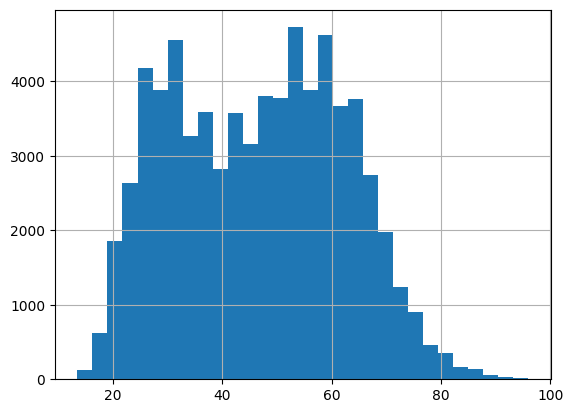

In [30]:
df_demo_clean["clnt_age"].hist(bins=30)

### Age distribution insights

- The majority of clients fall between 30 and 60 years old.
- The distribution is slightly right-skewed, with fewer older clients extending the tail.
- Very few clients are younger than 20.
- This suggests that the primary users of the platform are middle-aged rather than young clients.

In [31]:
df_demo_clean[["clnt_age", "logons_6_mnth", "calls_6_mnth"]].corr()

,clnt_age,logons_6_mnth,calls_6_mnth
clnt_age,1.000000,0.084683,0.026734
logons_6_mnth,0.084683,1.000000,0.822217
calls_6_mnth,0.026734,0.822217,1.000000


### Client behavior insights

- Age shows almost no correlation with user activity (logons: ~0.08, calls: ~0.03).
- This suggests that client behavior is not strongly influenced by age.
- In contrast, logons and calls are highly correlated (~0.82).
- This indicates that highly engaged users tend to interact frequently across multiple channels.

In [32]:
df_demo_clean.groupby("gendr")[["logons_6_mnth", "calls_6_mnth"]].mean()

,logons_6_mnth,calls_6_mnth
gendr,,
F,5.287052,3.090745
M,5.885643,3.706837
U,5.516707,3.338488
X,6.000000,3.666667


### Behavior differences by gender

- There are small differences in activity levels across genders.
- Male clients show slightly higher average logons and calls compared to female clients.
- However, the differences are relatively minor overall.
- This suggests that user behavior is fairly consistent across gender groups.
- The "X" category has very few observations and is not statistically reliable.

In [33]:
df_demo_clean["logons_6_mnth"].describe()

count    70594.000000
mean         5.566720
std          2.353296
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max          9.000000
Name: logons_6_mnth, dtype: float64

### Engagement level insights

- The average number of logons over 6 months is around 5.6, with a median of 5.
- Most users fall between 4 and 7 logons, indicating moderate engagement.
- The distribution is relatively tight, with few extreme values.
- This suggests that user activity levels are fairly consistent across the client base.

### Key insights from demographic analysis

- The majority of clients are middle-aged (30–60 years old).
- Gender distribution is relatively balanced across the dataset.
- Age shows almost no correlation with user activity.
- Behavior is also fairly consistent across gender groups, with only minor differences.

### Behavior insights

- Logons and calls are strongly correlated (~0.82), indicating consistent engagement patterns.
- Users who are active in one channel tend to be active in others as well.
- Overall engagement levels are moderate, with most users logging in 4–7 times over 6 months.
- There are no clear high-activity or low-activity segments based on demographics.

### Implications for next steps

- Demographic variables (age, gender) may not be strong predictors of behavior.
- Behavioral metrics should be the focus for further analysis.
- We should confirm whether demographic patterns differ after merging with experiment data.

### Data cleaning decisions (demographics)

- Rows with missing values were removed due to low impact.
- Tenure in months was kept as the main variable, as it is more precise than years.
- Tenure in years was dropped due to inconsistency.
- Gender values were kept as is, including "U" (unknown).

In [35]:
df_demo_clean.to_csv("../vanguard_AB/data/clean/df_demo_clean.csv", index=False)